This notebook is used to walk through building up an MAE using a subset of the Dec 17, 2023 Nore'easter data. Data is 239 images from epoch num: 1702827001820_all frames. The data was made in metashape using the refeernce method (needs to be updated). Last edits: 02/20/2026 BG

Continuous time series chunks 04/14/26

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import glob

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image
from scipy.io import loadmat

2026-05-04 08:30:08.258652: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# paths
MAE_datapath= r"/Volumes/kanarde/MasonBEAST/data/StormCHAZerz Data/Dec2023Noreaster_Processed/1702827001820_allframes/MAE"
# /Volumes/kanarde/MasonBEAST/data/StormCHAZerz Data/Dec2023Noreaster_Processed/1702827001820_allframes/MAE/Transects/1702827001820_allframes_7.3_2_raw.mat
# /Volumes/kanarde/MasonBEAST
transectpath=os.path.join(MAE_datapath,'Transects/')
rawdatapath=os.path.join(transectpath,'1702827001820_allframes_7.3_2_raw.mat')
autoencoderpath=os.path.join(transectpath,'17202827001820_allframes_7.3_2_autoencoder') # update as needed for saving 
gausspath=os.path.join(transectpath,'17202827001820_allframes_7.3_2_gauss') # update as needed for saving 
MAEpath=os.path.join(transectpath,'17202827001820_allframes_7.3_2_MAE') # update as needed for saving 

In [3]:
# load in matfile and convert
raw_transects=loadmat(rawdatapath)

In [4]:
transects=raw_transects['ztran']
transect_df_raw=pd.DataFrame(transects) # convert to dataframe

In [5]:
print(transect_df_raw)

          0         1         2    3    4    5    6      7    8      9    ...  \
0         NaN       NaN  4.092429  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
1         NaN       NaN  4.092429  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
2         NaN       NaN       NaN  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
3         NaN       NaN       NaN  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
4         NaN       NaN       NaN  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
..        ...       ...       ...  ...  ...  ...  ...    ...  ...    ...  ...   
546  0.765234  0.822544  1.435690  NaN  NaN  NaN  NaN  0.997  NaN    NaN  ...   
547  0.761258  0.871067  1.430057  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
548  0.753258  0.958421  1.442268  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
549  0.764375  1.048709  1.487136  NaN  NaN  NaN  NaN    NaN  NaN    NaN  ...   
550  0.774625  1.163879       NaN  NaN  NaN  NaN  NaN  0.976  NaN  0.929  ...   

     229  230  231     232 

TRYING TO SPLIT MORE EFFICIENTLY

In [189]:
# NEED TO NORMALIZE DATA
all_vals=transect_df_raw.values.flatten()
all_vals=all_vals[~np.isnan(all_vals)]

min_elev=np.min(all_vals)
print("Minimum elev:", min_elev,"m")
max_elev=np.max(all_vals)
print("Max elev:", max_elev,"m")

def normalize(x):
    return (x-min_elev)/(max_elev-min_elev)
def denormalize(x):
    return x*(max_elev-min_elev)+min_elev

transect_df_norm=(transect_df_raw-min_elev)/(max_elev-min_elev)

Minimum elev: 0.355 m
Max elev: 4.2831 m


In [202]:
def prep_dataset_windows(df_norm,window_size=10,stride=5):
    # fill nans with 0
    data=tf.convert_to_tensor(df_norm.fillna(0).values,dtype=tf.float32)

    ds=tf.data.Dataset.from_tensor_slices(data)
    ds=ds.window(window_size,shift=stride,drop_remainder=True) # (window size, 239)

    ds=ds.flat_map(lambda x: x.batch(window_size))
    # add channel dim
    # (window_size,239,1)
    ds=ds.map(lambda x: tf.expand_dims(x,axis=-1))

    return ds

ds=prep_dataset_windows(transect_df_norm,window_size=10,stride=5)

# shuffle and batch for model
ds=ds.shuffle(1000).batch(16).prefetch(tf.data.AUTOTUNE)

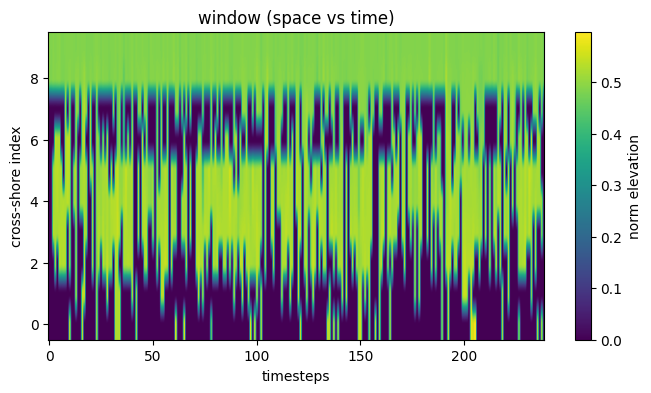

In [194]:
def vis_window(window_tensor):
    #(height,width,1)
    plt.figure(figsize=(8,4))
    plt.imshow(window_tensor.numpy().squeeze(),aspect='auto',cmap='viridis',origin='lower')
    plt.colorbar(label='norm elevation')
    plt.title("window (space vs time)")
    plt.xlabel('timesteps')
    plt.ylabel('cross-shore index')
    plt.show()

for window in ds.take(1):
    vis_window(window[0])


In [195]:
# split into training, testing, val
ds_size=len(list(ds))
train_size=int(0.8*ds_size)
val_size=int(0.1*ds_size)
test_size=ds_size-train_size-val_size

train_ds=ds.take(train_size)
test_ds=ds.skip(train_size)
val_ds=test_ds.skip(val_size)
test_ds=test_ds.take(test_size)

# optimization ??
train_ds=train_ds.prefetch(tf.data.AUTOTUNE)
val_ds=val_ds.prefetch(tf.data.AUTOTUNE)

In [206]:
class MaskingLayer(tf.keras.layers.Layer):
    def __init__(self,mask_ratio=0.3,**kwargs):
        super().__init__(**kwargs)
        self.mask_ratio=mask_ratio

    def call(self,inputs):
        mask=tf.random.uniform(tf.shape(inputs)) < self.mask_ratio
        mask=tf.cast(mask,tf.float32)
        masked_x=inputs*(1-mask)
        return masked_x, mask

In [207]:
class MAEModel(tf.keras.Model):
    def __init__(self, input_dim=239, window_size=10, latent_dim=128):
        super().__init__()
        self.masking_layer = MaskingLayer(mask_ratio=0.25)
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(512, activation='relu'),
            tf.keras.layers.Dense(latent_dim)
        ])
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Dense(512, activation='relu'),
            tf.keras.layers.Dense(window_size * input_dim)
        ])

    def train_step(self, data):
        # Data in this context is the windowed input batch
        with tf.GradientTape() as tape:
            masked_input, mask = self.masking_layer(data)
           
            # Forward pass
            latent = self.encoder(masked_input)
            reconstructed = self.decoder(latent)
            reconstructed = tf.reshape(reconstructed, tf.shape(data))
           
            # Custom Loss: MSE only on masked values
            mse = tf.square(reconstructed - data)
            # Apply mask to keep only the errors on hidden values
            masked_loss = tf.reduce_sum(mse * mask) / (tf.reduce_sum(mask) + 1e-8)
           
        trainable_vars = self.trainable_variables
        gradients = tape.gradient(masked_loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
       
        return {"loss": masked_loss}

In [208]:
model=MAEModel()
model.compile(optimizer='adam')

model.fit(ds,epochs=10)

Epoch 1/10


ValueError: in user code:

    File "/Users/bagaenzl/MasonBEAST/.venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 1338, in train_function  *
        return step_function(self, iterator)
    File "/Users/bagaenzl/MasonBEAST/.venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 1322, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/Users/bagaenzl/MasonBEAST/.venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 1303, in run_step  **
        outputs = model.train_step(data)
    File "/var/folders/q5/f29tpv495_l1nlg9kcr2kl0w0000gx/T/ipykernel_80832/4208746305.py", line 21, in train_step
        latent = self.encoder(masked_input)
    File "/Users/bagaenzl/MasonBEAST/.venv/lib/python3.8/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/Users/bagaenzl/MasonBEAST/.venv/lib/python3.8/site-packages/k

OLD WAY GETTING BUGS IN SIZE?

In [16]:
# NEED TO NORMALIZE DATA
all_vals=transect_df_raw.values.flatten()
all_vals=all_vals[~np.isnan(all_vals)]

min_elev=np.min(all_vals)
print("Minimum elev:", min_elev,"m")
max_elev=np.max(all_vals)
print("Max elev:", max_elev,"m")

def normalize(x):
    return (x-min_elev)/(max_elev-min_elev)
def denormalize(x):
    return x*(max_elev-min_elev)+min_elev

transect_df_norm=(transect_df_raw-min_elev)/(max_elev-min_elev)

Minimum elev: 0.355 m
Max elev: 4.2831 m


In [17]:
windows={} # window dictionary
window_idx={} # indexes

for timestep,transect in transect_df_norm.items():
    arg=transect.values
    masked=np.ma.masked_invalid(arg)
    clumps=np.ma.clump_unmasked(masked)

    windows[timestep]=[arg[s] for s in clumps]
    window_idx[timestep]=[(s.start,s.stop) for s in clumps]

    #print(f"Window length is: {len(arg)}") printing length of transect

break up continous sets into chosen length then build up masking ratio in MAE

In [8]:
# function to split up windows based on chosen threshold
# have windows slightly overlap

def window_split(start,stop,size,overlap):
    return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]



In [18]:
size=10 # chosen windwo size
split_windows_idx={}
# split windows to chosen length
for timestep in window_idx:
    newwindows=[]
    for (start,stop) in window_idx[timestep]:
        length=stop-start
        if length>=size: #skipping over windows less than chosen length
            newwindows.extend(window_split(start,stop,size,size/4)) # right now windows overlap 75%

    split_windows_idx[timestep]=newwindows

/var/folders/q5/f29tpv495_l1nlg9kcr2kl0w0000gx/T/ipykernel_741/3836236576.py:30: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm,label='window length')


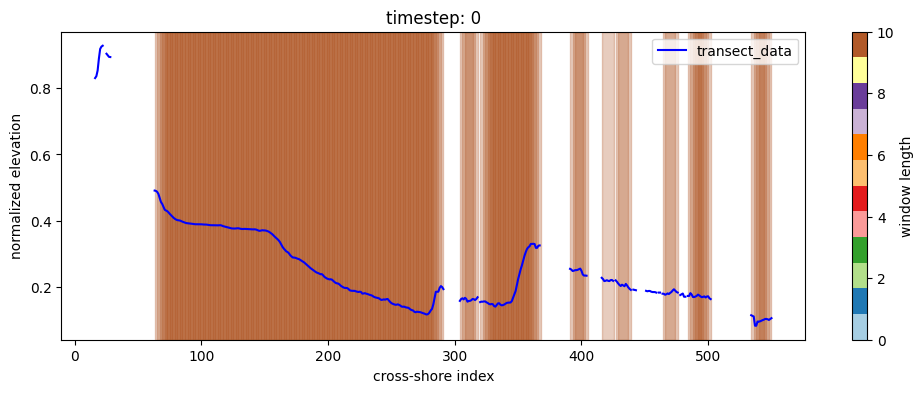

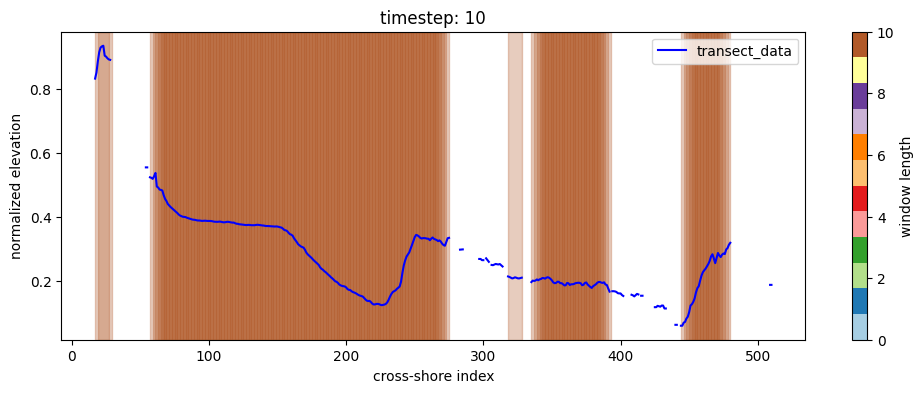

In [19]:
# check function 
# plot the windows
timesteps=[0,10]#,20,40,60,80,100]

cmap=plt.cm.Paired
norm=plt.Normalize(0,size)

for timestep in timesteps:
    transect=transect_df_norm[timestep]

    aeta=transect.values
    crossDist=np.arange(len(aeta))

    plt.figure(figsize=(12,4))

    plt.plot(crossDist,aeta,color='blue',label='transect_data') # plot transect

    for (start,stop) in split_windows_idx[timestep]:
        length=stop-start
        color=cmap(norm(length))
        plt.axvspan(start,stop,color=color,alpha=0.3)

    plt.title(f"timestep: {timestep}")
    plt.xlabel("cross-shore index")
    plt.ylabel("normalized elevation")

    # color bar
    sm=plt.cm.ScalarMappable(cmap=cmap,norm=norm)
    sm.set_array([])
    plt.colorbar(sm,label='window length')
    plt.legend()

    plt.show()

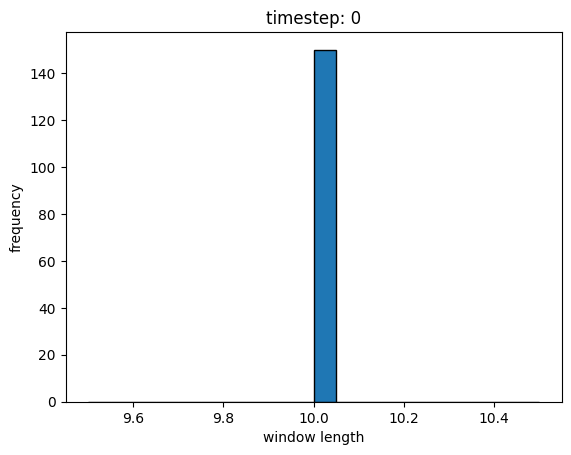

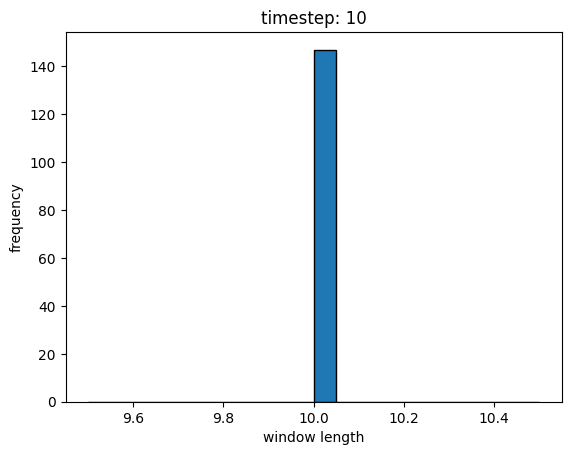

In [20]:
# double check histogram of lengths in transect
for timestep in timesteps:
    lengths=[stop-start for (start,stop) in split_windows_idx[timestep]]

    plt.hist(lengths,bins=20,edgecolor='black')
    plt.title(f"timestep: {timestep}")
    plt.xlabel("window length")
    plt.ylabel("frequency")

    plt.show()

In [153]:
# store new windows as training and testing of MAE
transects_split=[]
info=[] # (timestep, start, stop)

for timestep in split_windows_idx:
    transect=transect_df_norm[timestep].values

    for (start,stop) in split_windows_idx[timestep]: #loop through all window image pairs 
        window=transect[start:stop]

        if len(window)==(stop-start): #double check window length is right
            transects_split.append(window)
            info.append((timestep,start,stop)) #where window came from info

In [154]:
transects_split=np.array(transects_split)

In [155]:
print(transects_split.shape) # number of windows, length of windows
# this is total amount of possible training,testing,val data

(37686, 10)


In [156]:
# split into training, testing, and validation data
timesteps=sorted(split_windows_idx.keys()) # list of timesteps in order

# split up by time
n=len(timesteps)

train_end=int(n*0.7) #first 70% training
val_end=int(n*0.85) # then 15% validation

train_time=timesteps[:train_end] 
val_time=timesteps[train_end:val_end]
test_time=timesteps[val_end:] #15% test

X_train,X_test,X_val=[],[],[]
info_train,info_test,info_val=[],[],[]
for t in train_time:
    transect=transect_df_norm[t].values
    for (start,stop) in split_windows_idx[t]:
        X_train.append(transect[start:stop])
        info_train.append({'timestep':t,'start':start,'stop': stop})

for t in val_time:
    transect=transect_df_norm[t].values
    for (start,stop) in split_windows_idx[t]:
        X_val.append(transect[start:stop])
        info_val.append({'timestep':t,'start':start,'stop': stop})

for t in test_time:
    transect=transect_df_norm[t].values
    for (start,stop) in split_windows_idx[t]:
        X_test.append(transect[start:stop])
        info_test.append({'timestep':t,'start':start,'stop': stop})

In [157]:
# convert datat to arrays for MAE
X_train=np.array(X_train)
X_train=X_train.astype("float32")
X_test=np.array(X_test)
X_test=X_test.astype("float32")
X_val=np.array(X_val)
X_val=X_val.astype("float32")

In [158]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(26361, 10)
(5198, 10)
(6127, 10)


In [159]:
train_starts=np.array([i['start'] for i in info_train])
train_timesteps=np.array([i['timestep'] for i in info_train])
train_ds=tf.data.Dataset.from_tensor_slices((np.array(X_train),np.array(train_starts),np.array(train_timesteps)))

test_starts=np.array([i['start'] for i in info_test])
test_timesteps=np.array([i['timestep'] for i in info_test])
test_ds=tf.data.Dataset.from_tensor_slices((np.array(X_test),np.array(test_starts),np.array(test_timesteps)))

val_starts=np.array([i['start'] for i in info_val])
val_timesteps=np.array([i['timestep'] for i in info_val])
val_ds=tf.data.Dataset.from_tensor_slices((np.array(X_val),np.array(val_starts),np.array(val_timesteps)))

In [160]:
# define model
# right now using a window length of 10 so need to build up back to 10, if size is a multiple of 8 it's much easier for building up
class Denoise(Model):
    def __init__(self):
        super(Denoise,self).__init__()

        self.encoder=tf.keras.Sequential([
            layers.Input(shape=(10,2)), # changed from none
            layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(8,3,activation='relu',padding='same',strides=2)
        ])

        self.decoder=tf.keras.Sequential([
            layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
            layers.Conv1D(1,3,activation='sigmoid',padding='same'), #normalized output
            layers.Cropping1D((0,6)) # builds up to 16, need length of 10
            #x=layers.Dense(10,activation='sigmoid')(x) 
        ])

    def call(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return decoded
    
    def train_step(self,data):
        # to get input tensor (x_input,y) from .map() in mask
        x_input,y, mask,start_idx,t_step = data #(batch,10,2) (batch,10,1) (batch,10,1)

        #x_input,mask=masking_layer(x) # apply mask
        #x_masked=x_input[:,:,:2]
        with tf.GradientTape() as tape: 
            # forward pass using x_masked
            y_pred=self(x_input,training=True)
            # calc loss
            #mask=x_input[:,:,1:2] #grab mask from 2nd channel
            mse=tf.square(y_pred-y) #calc loss
            masked_mse=mse*(1.0 - mask) # masked loss
            loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points
        trainable_vars=self.trainable_variables
        gradients=tape.gradient(loss,trainable_vars)
        self.optimizer.apply_gradients(zip(gradients,trainable_vars))

        return{"loss":loss}
    
    def test_step(self,data):
         # to get input tensor
        x,y,mask,start_idx,t_step=data
        
        #x_input,mask=masking_layer(x) # apply mask
        #x_masked=x_input[:,:,:2]
        y_pred=self(x,training=False)

        #mask=x_input[:,:,1:2]
        mse=tf.square(y_pred-y) #calc loss
        masked_mse=mse*(1.0 - mask) # masked loss
        loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

        return {"loss":loss}
        

    
autoencoder=Denoise()
autoencoder.compile(optimizer='adam',loss='mse')

def gap_mask(x,mask_ratio):
     #batch_size=tf.shape(x)[0]
     length=tf.shape(x)[0]# number of things in x, x is (10,1)

     gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
     gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
     max_start=tf.maximum(length-gap_size,0) #mask starts inside window

     start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask

     #mask=tf.ones_like((batch_size,length,1),dtype=tf.float32) # 1D mask (batch,length,1)

     #idx=tf.range(start,start+gap_size) # gap indices
     #idx=tf.expand_dims(idx,axis=1) #add dimension (block_size,1)
     range_idx=tf.range(length) # (length,) 
     #range_idx=tf.expand_dims(range_idx,0) #(1,length)
     #range_idx=tf.tile(range_idx,[batch_size,1]) # (batch, length)

     #start_extra_dim=tf.reshape(start,[batch_size,1]) # (batch,1)
     #boolean mask
     if_in_gap=tf.logical_and(range_idx>=start,range_idx<(start+gap_size))

     gap_mask_tensor=tf.cast(if_in_gap,tf.float32)
     gap_mask_tensor=tf.expand_dims(gap_mask_tensor,-1) # 1 at gap, 0 everywhere else (batch,length,1)
     mask=1-gap_mask_tensor
     #mask=1-tf.expand_dims(tf.cast(if_in_gap,tf.float32),axis=-1)# 0 is gap 1 is not (batch,length,1)
    
     #updates=tf.zeros((batch_size,gap_size,1),dtype=tf.float32)# zeros at made gaps
     #mask=tf.tensor_scatter_nd_update(mask,idx,updates)

     #batch_idx=tf.range(batch_size)
     #batch_idx=tf.expand_dims(batch_idx,-1) # (batch,1)
     #atch_idx=tf.tile(batch_idx,[1,gap_size]) # (batch,gap_size)

     #seq_idx=tf.tile(tf.expand_dims(idx,0),[batch_size,1]) #(batch, gap_size)

     #ndx=tf.stack([batch_idx,seq_idx],axis=-1) # (batch, gap_size, 2)

     #mask=tf.tensor_scatter_nd_update(mask,indx,updates)
     
     x_masked=x*mask
     return x_masked,mask

def random_mask(x,mask_ratio):
    #batch=tf.shape(x)[0]
    #length=tf.shape(x)[1]
    #shape=[tf.shape(x)[0],tf.shape(x)[1],1] # list [batch,length,1]
    mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32) # mask is is (batch,length,1) and x_masked is (batch,length,2)
    x_masked=x*mask
    return x_masked, mask


def masking_layer(x,start,t_step):
    #x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x # (length,1)

    #x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x #check right shape or add dimension (length,1)
    #x=tf.expand_dims(x,axis=0) #(1,length)
    #x=tf.convert_to_tensor(x)
    x=tf.reshape(tf.cast(x,tf.float32),[10,1]) # 10 is window length
    mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

    use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
    #mask via gap and random method
    x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))

    #x_masked=tf.convert_to_tensor(x_masked)
    #mask=tf.convert_to_tensor(mask)
    # mask as a second channel
    #if mask.shape.rank==1:
        #mask=tf.expand_dims(mask,axis=1)
    #mask=tf.tile(mask,[1,10,1])
    #mask.set_shape([10,1])
    #x_masked.set_shape([10,1])
    x_input=tf.concat([x_masked,mask],axis=-1) # now (1,length,2)

    #tf.print("running mask layer- x_masked shape:", tf.shape(x_masked))
    #tf.print("running masked layer- mask shape:", tf.shape(mask))


    return x_input,x, mask, start, t_step# (given data and target/real og data)


In [161]:
# test masking function
x=tf.ones((10,1))
x_masked,mask=gap_mask(x,0.5)

print("x masked:",x_masked.numpy().flatten())
print("mask:",mask.numpy().flatten())

x masked: [0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
mask: [0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]


In [162]:
batch_size=16
# grab data from X_train, mask, .AUTOTUNE oarallelizes (for speed? via internet), batch groups of 16, prefetch preps next batch while training on the 1st
train_ds=(
    train_ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size, drop_remainder = True).prefetch(tf.data.AUTOTUNE))


val_ds=(
    val_ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE))

test_ds=(
    test_ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE))

#val_ds=val_ds.padded_batch(10,padded_shapes=([None,2],[None,10,1]) )

In [163]:
for x_input,y,mask,start,tstep in train_ds.take(5):
    print('x inpu shape:', x_input.shape)
    print('y shaep:', y.shape)

x inpu shape: (16, 10, 2)
y shaep: (16, 10, 1)
x inpu shape: (16, 10, 2)
y shaep: (16, 10, 1)
x inpu shape: (16, 10, 2)
y shaep: (16, 10, 1)
x inpu shape: (16, 10, 2)
y shaep: (16, 10, 1)
x inpu shape: (16, 10, 2)
y shaep: (16, 10, 1)


In [165]:
for x_input,y_true,mask, s_idx, t_idx in train_ds.take(1):
    print(f"input shape: {x_input.shape}")
    print(f"start index: {s_idx[0]}")
    print(f"timestep: {t_idx[0]}")

input shape: (16, 10, 2)
start index: 63
timestep: 0


In [164]:
#TRAIN

autoencoder=Denoise()
#autoencoder.compile(optimizer='adam',loss='mse') DONT NEED SIMCE TRAINING STEP FUNCTION
autoencoder.compile(optimizer='adam')

history=autoencoder.fit(train_ds,validation_data=val_ds,epochs=20) #epochs 20 for testing

Epoch 1/20
1647/1647 [==============================] - 7s 4ms/step - loss: 0.0058 - val_loss: 4.2554e-04
Epoch 2/20
1647/1647 [==============================] - 6s 4ms/step - loss: 7.0393e-04 - val_loss: 2.5157e-04
Epoch 3/20
1647/1647 [==============================] - 6s 4ms/step - loss: 6.2379e-04 - val_loss: 2.6350e-04
Epoch 4/20
1647/1647 [==============================] - 7s 4ms/step - loss: 5.1460e-04 - val_loss: 1.1089e-04
Epoch 5/20
1647/1647 [==============================] - 7s 4ms/step - loss: 5.6855e-04 - val_loss: 1.9989e-04
Epoch 6/20
1647/1647 [==============================] - 8s 5ms/step - loss: 5.1967e-04 - val_loss: 1.6833e-04
Epoch 7/20
1647/1647 [==============================] - 7s 5ms/step - loss: 4.0781e-04 - val_loss: 1.8899e-04
Epoch 8/20
1647/1647 [==============================] - 7s 5ms/step - loss: 4.7757e-04 - val_loss: 8.9010e-05
Epoch 9/20
1647/1647 [==============================] - 7s 4ms/step - loss: 4.5261e-04 - val_loss: 1.6553e-04
Epoch 10/20
16

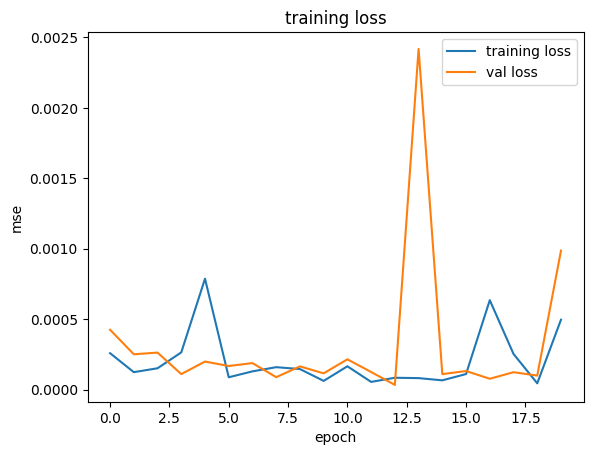

In [166]:
# plot loss curve
# plot training loss
plt.figure()
plt.plot(history.history['loss'],label='training loss')
plt.plot(history.history['val_loss'],label='val loss')
plt.legend()
plt.xlabel("epoch")
plt.ylabel('mse')
plt.title('training loss')
plt.show()

# training loss shows how it's learning (rapid learning then levels off) Val loss shows how model performs on unseen data (it's decreasing so yay!)

look at small window reconstruction

In [168]:
for x_batch,y_batch,mask,start,t_step in test_ds.take(1):
    recons=autoencoder.predict(x_batch)
    break

1/1 [==============================] - 0s 165ms/step


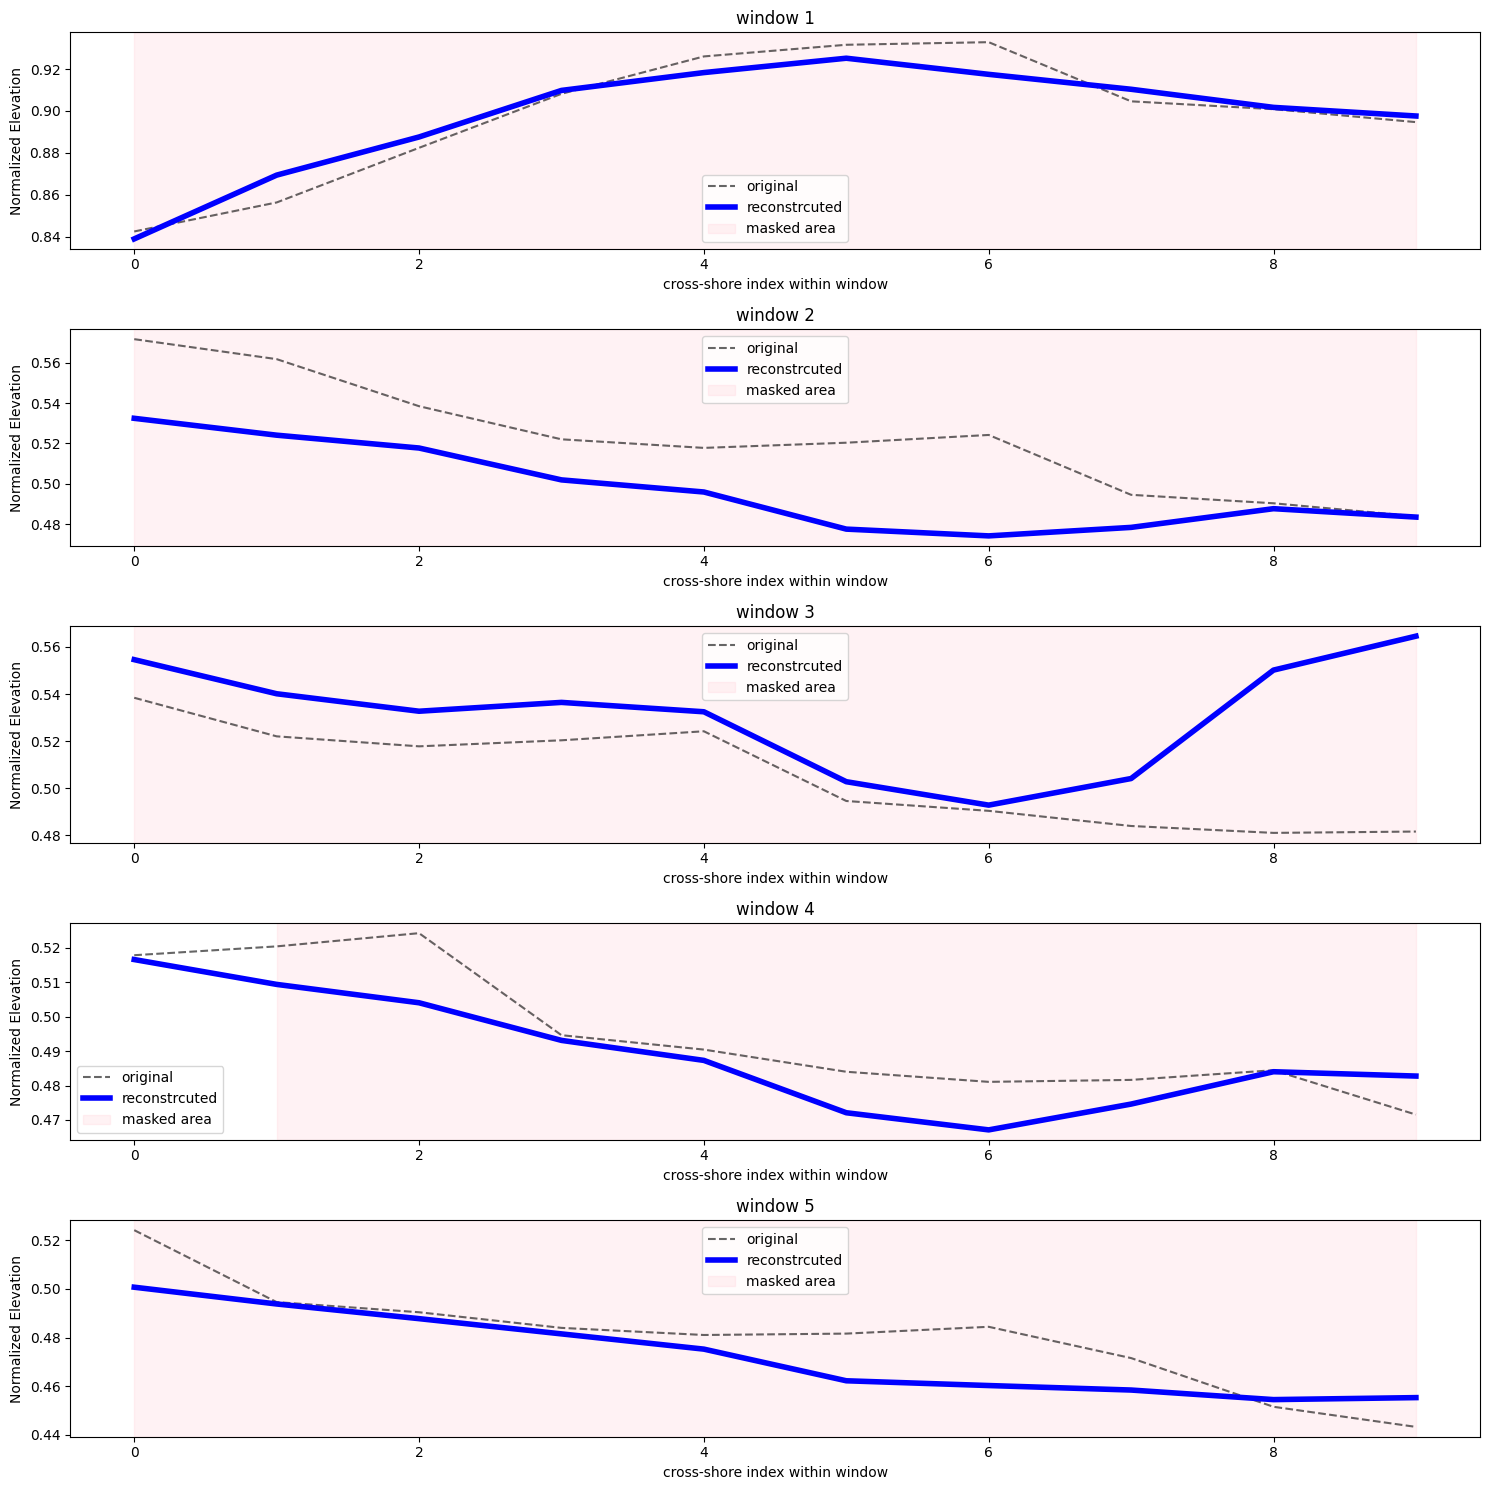

In [169]:
def plot_recons(y_true,x_input,y_pred,n=5):
    plt.figure(figsize=(15,3*n))
    for i in range(n):
        raw_input_val=x_batch[i,:,0]
        mask_channel=x_batch[i,:,1]

        plt.subplot(n,1,i+1)

        # plot true val
        plt.plot(y_true[i],label='original',color='black',linestyle='--', alpha=0.6)
        # plot prediction
        plt.plot(y_pred[i],label='reconstrcuted',color='blue',linewidth=4)

        # highlight mask gaps
        gap_idx=np.where(mask[i]>0)[0]
        if len(gap_idx)>0:
            plt.axvspan(gap_idx[0],gap_idx[-1],color='pink',alpha=0.2, label='masked area')
        plt.ylabel('Normalized Elevation')
        plt.xlabel('cross-shore index within window')
        plt.title(f"window {i+1}")
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_recons(y_batch,x_batch,recons,n=5)


In [223]:
def plot_windows_on_fullTran(y_true,x_input,y_pred,start_idx,timestep,transect_df_norm,mask_batch,n):
    fig,axes=plt.subplots(n,2,figsize=(20,4*n))

    for i in range(n):
        tval=timestep[i].numpy().decode('utf-8') if isinstance(timestep[i].numpy(), bytes) else timestep[i].numpy()
        sval=int(start_idx[i].numpy())

        fullTran=transect_df_norm[tval].values

        global_x_axis=np.arange(sval,sval+10)

        # left side full transect
        ax_full=axes[i,0]
        ax_full.plot(fullTran,color='lightgray',alpha=0.5,label='full transect')
        ax_full.plot(global_x_axis,y_true[i].numpy().flatten(),color='black',label='original', linewidth=2)
        ax_full.plot(global_x_axis,y_pred[i].flatten(),color='blue',label='reconstructed',linewidth=2)
        # zoom in box
        ax_full.axvspan(sval,sval+10,color='pink',alpha=0.3,label='window')
        ax_full.set_title(f"full transect: {tval}")
        ax_full.legend(loc='upper right')

        # right side zoomed in window
        ax_zoom=axes[i,1]
        ax_zoom.plot(global_x_axis,y_true[i].numpy().flatten(),color='black',label='original', linewidth=2)
        ax_zoom.plot(global_x_axis,y_pred[i].flatten(),color='blue',label='reconstructed',linewidth=2)
        padding=15
        mask=mask_batch[i].numpy().flatten()
        gap_idx=np.where(mask>0)[0]

        if len(gap_idx)>0:
            gapstart=global_x_axis[gap_idx[0]]
            gapend=global_x_axis[gap_idx[-1]]

            ax_zoom.axvspan(gapstart,gapend,color='green',alpha=0.15,label='mask')

        #local_seg=fullTran[max(0,sval-padding):min(len(fullTran),sval+10+padding)]
        ax_zoom.set_ylim(0,1)
        ax_zoom.set_xlim(sval-2,sval+12)

        ax_zoom.set_title(f"zoomed in window (index {sval})")
        ax_zoom.grid(True,linestyle=':',alpha=0.6)
        ax_zoom.legend()


    plt.tight_layout()
    plt.show()


1/1 [==============================] - 0s 18ms/step


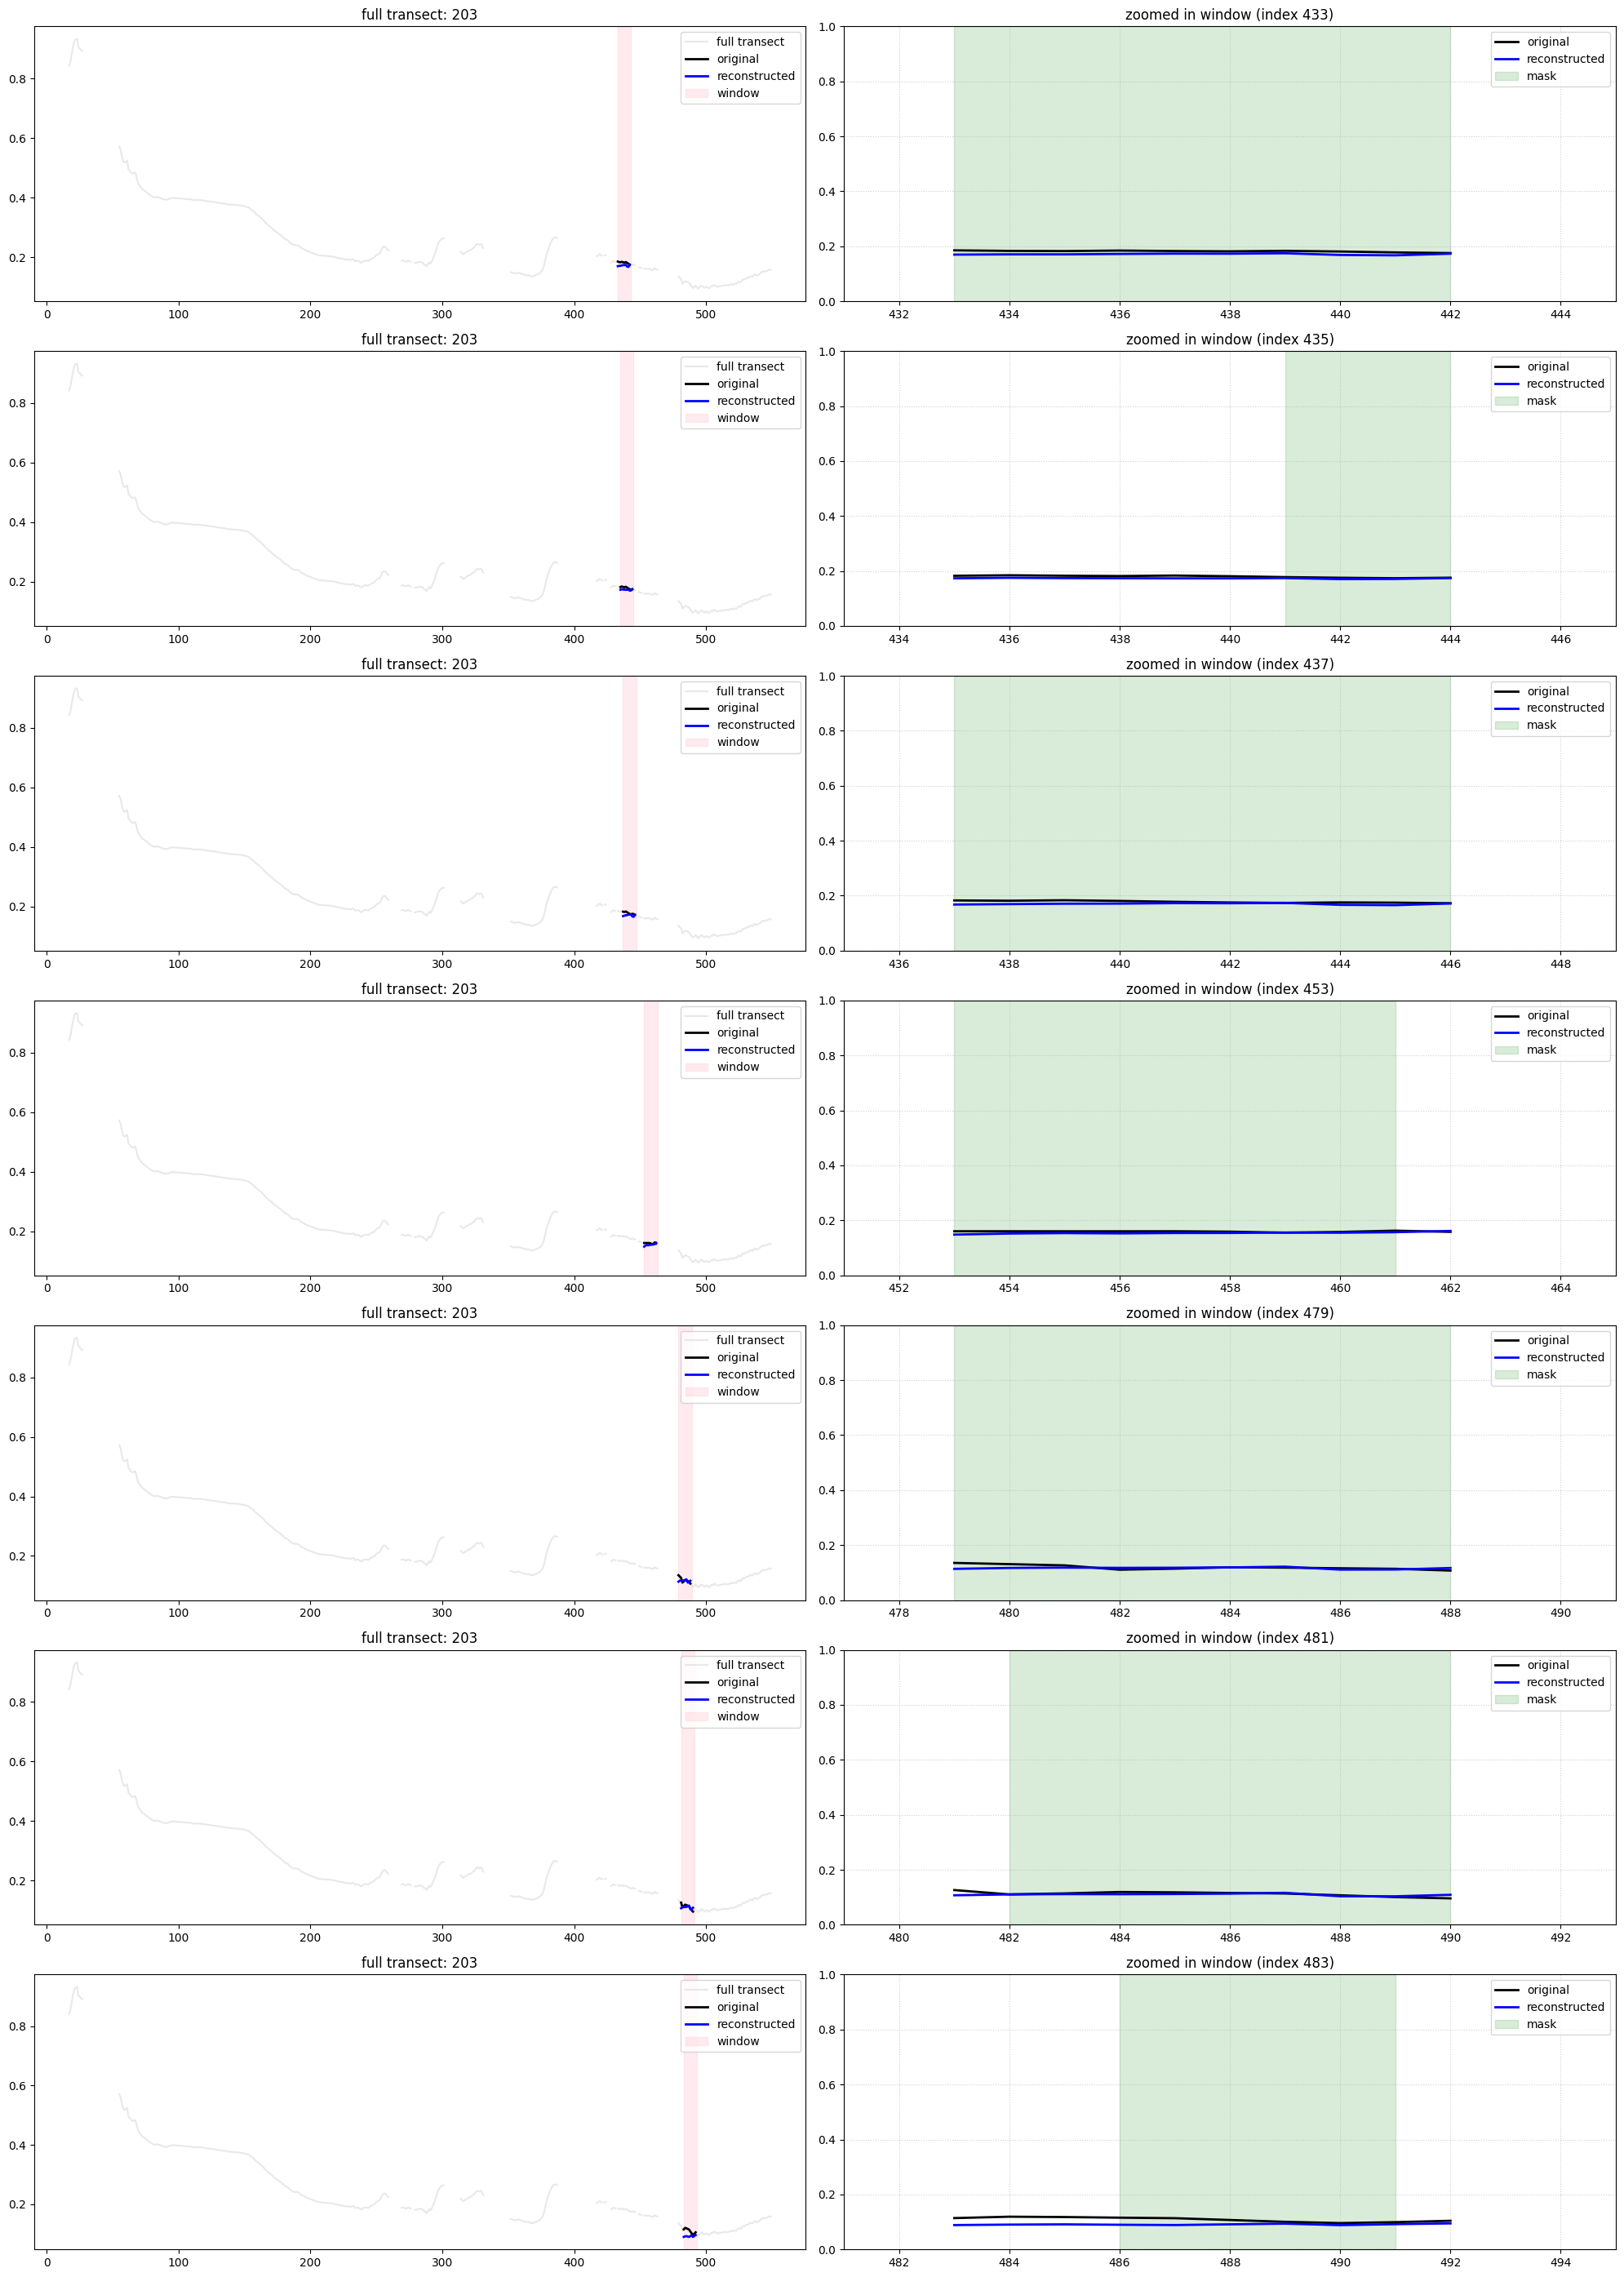

In [224]:
for x_batch,y_batch,mask_batch,s_batch,t_batch in test_ds.take(1):
    recons=autoencoder.predict(x_batch)
    plot_windows_on_fullTran(y_batch,x_batch,recons,s_batch,t_batch,transect_df_norm,mask_batch,n=7)

1/1 [==============================] - 0s 15ms/step


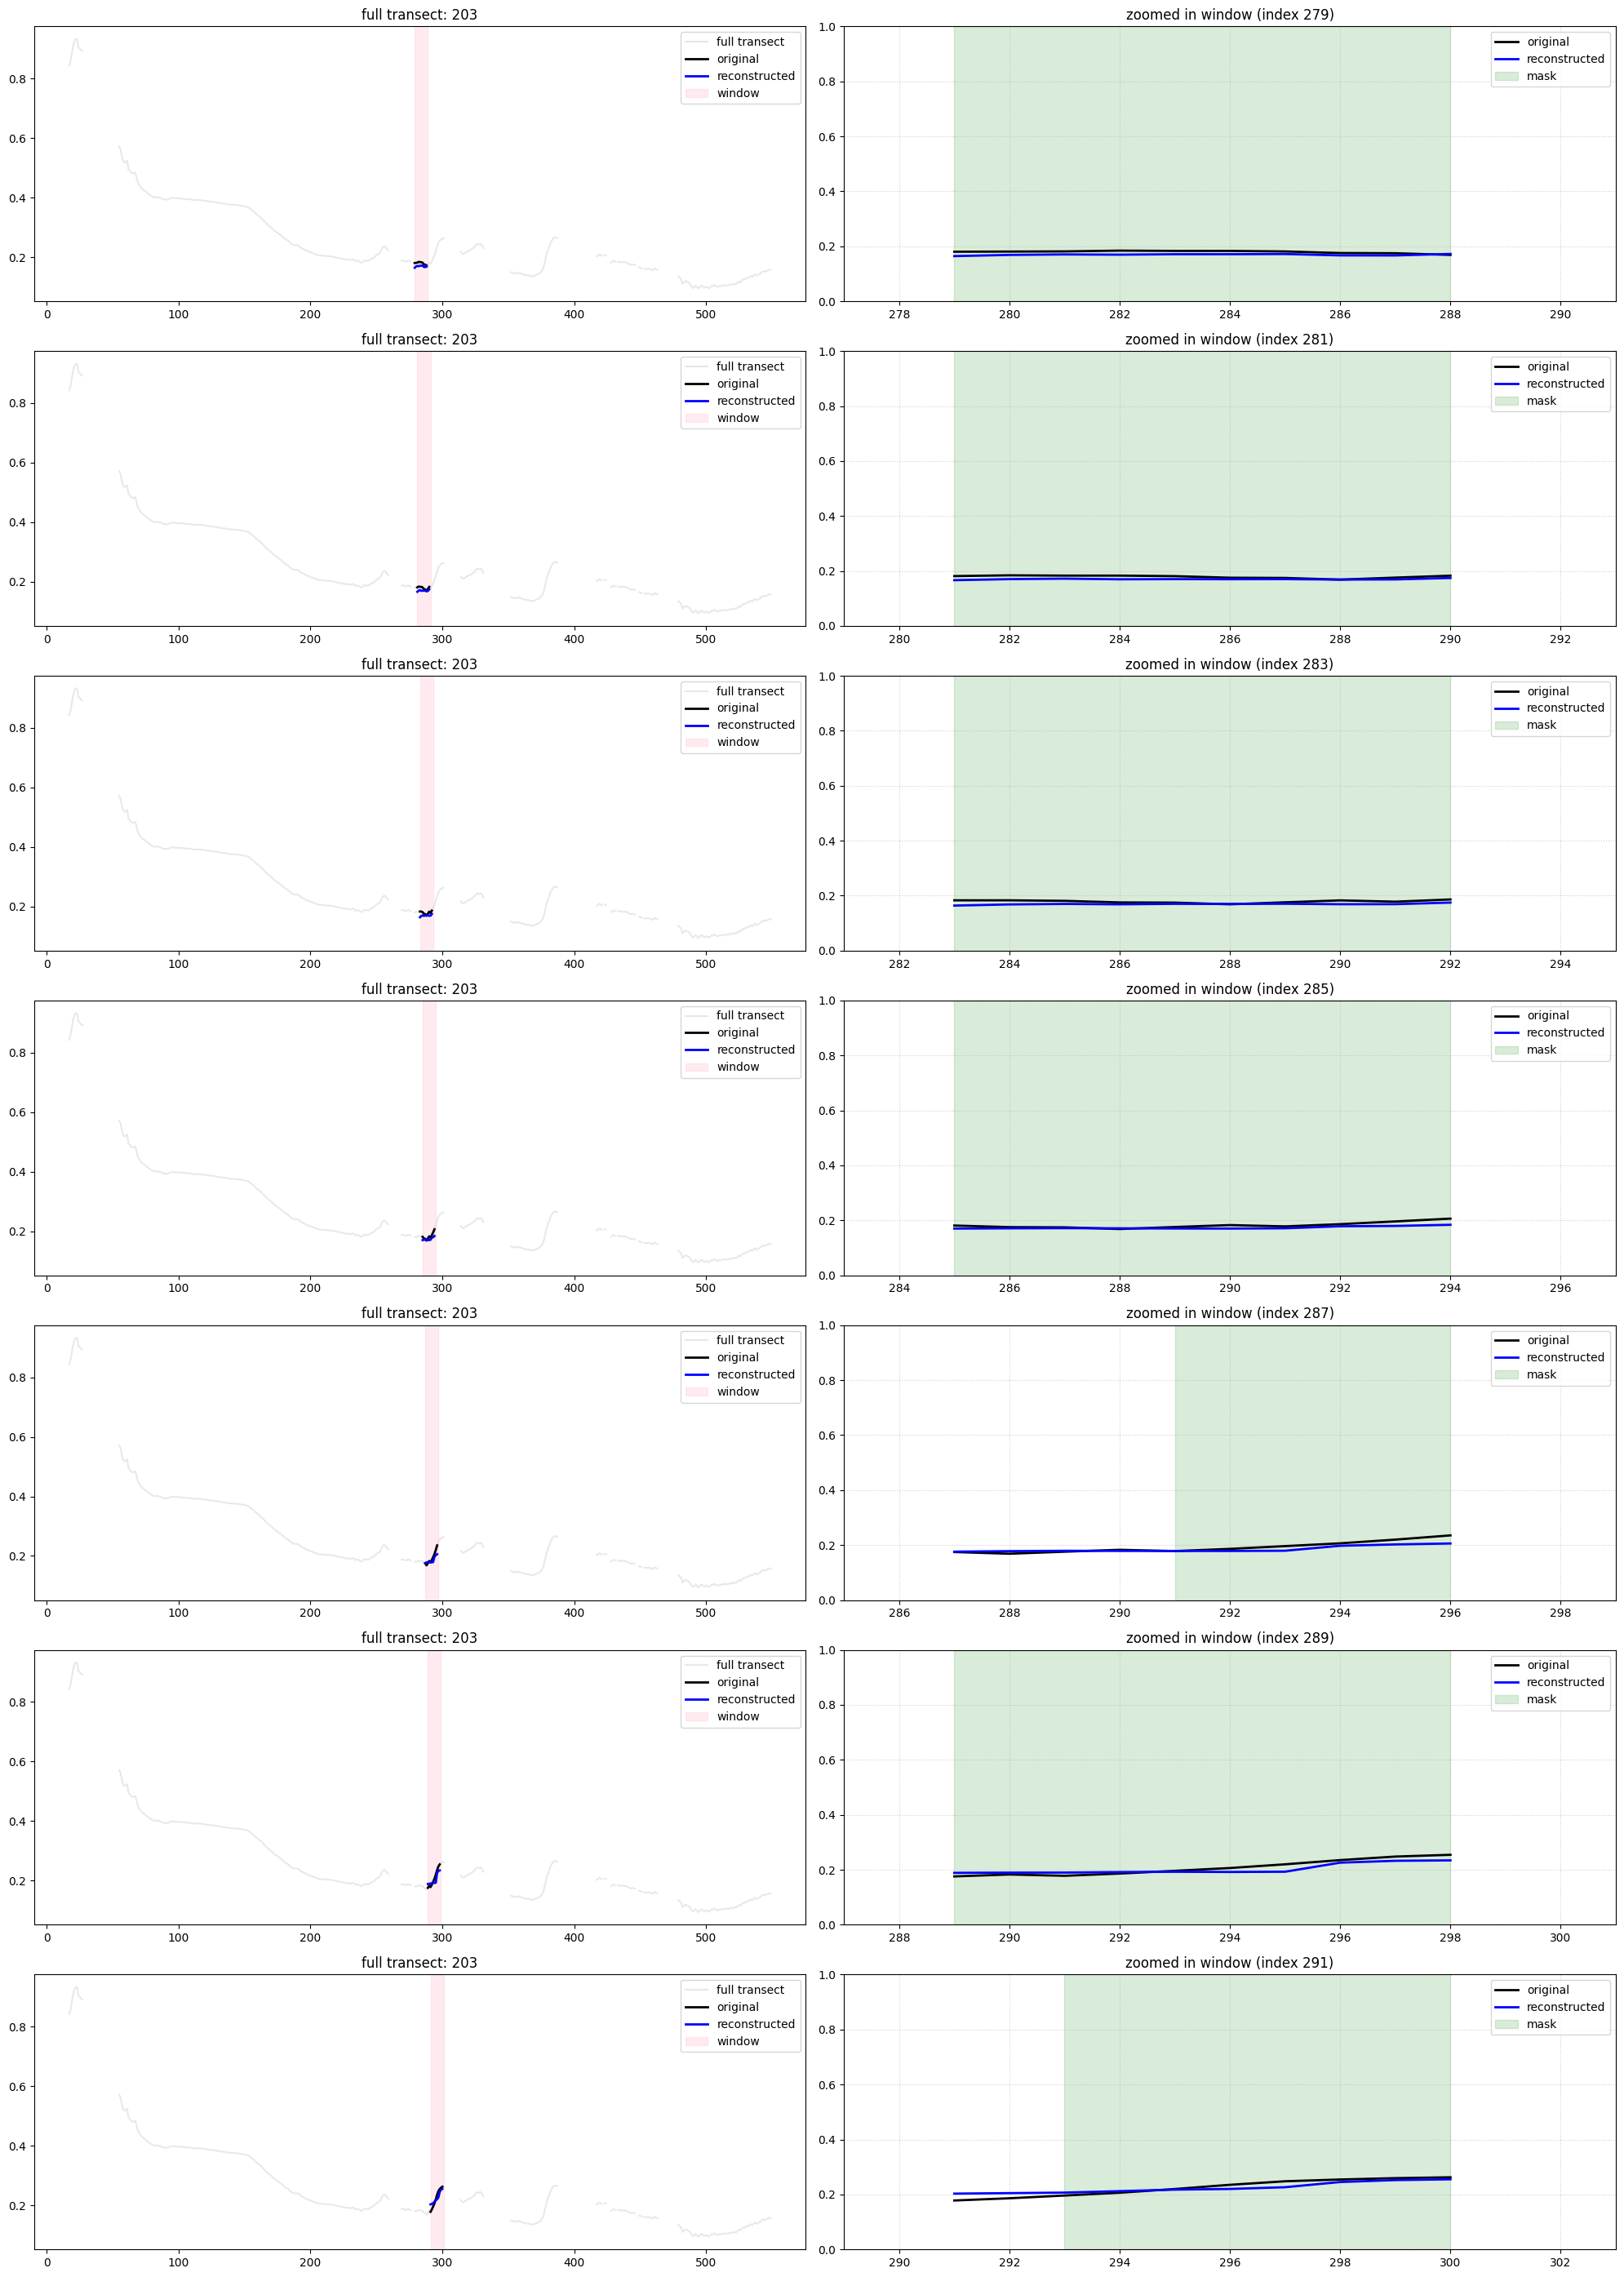

In [227]:
threshold=250

test_starts=np.array([i['start'] for i in info_test])
test_timesteps=np.array([i['timestep'] for i in info_test])
test_ds=tf.data.Dataset.from_tensor_slices((np.array(X_test),np.array(test_starts),np.array(test_timesteps)))

test_ds=(
    test_ds.filter(lambda x,s,t: s>threshold).map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE))

for x_batch,y_batch,mask_batch,s_batch,t_batch in test_ds.take(1):
    recons=autoencoder.predict(x_batch)
    plot_windows_on_fullTran(y_batch,x_batch,recons,s_batch,t_batch,transect_df_norm,mask_batch,n=7)

now that we've reconstrcuted with window length of 10, rehistogram and reconstruct a larger window

In [ ]:
# create new ds - SUBSET 1



OLDER THINGS BEFORE 05/03

In [128]:
# evaluate on gaps

def gap_eval(model,ds):
    total_error=0
    count=0

    for x_input, y_true in ds:
        x_masked=x_input[...,0:1] #input with masked vals
        mask=x_input[...,1:2]

        y_pred=model(x_input)

        gap=1-mask # gap1 mask0
        error=tf.reduce_sum(tf.abs((y_true-y_pred)*gap)) #recon error only at masks mean abs error
        total_error+=error
        count+=tf.reduce_sum(gap)

    return total_error/count #avg error over masked gaps
    
gap_Meanabserr=gap_eval(autoencoder,val_ds)
print("GAP Mean abs error:",gap_Meanabserr.numpy())

GAP Mean squeared error: 0.051347


In [129]:
# test on full transects

def recon_gaps(model,x,mask):
    # x is (551,239)
    # mask is (551,1)
    x_masked=x*mask
    x_input=tf.concat([x_masked,mask],axis=-1)# smoosh last dim (551,239+1mask dim)

    recon=model.predict(x_input[None,...])[0]#add batch dim,predict,delete batch dim

    filled=x*mask+recon*(1-mask)#where mask =1 filled is x, but when mask is 0 filled is reconstruction
    return filled


In [130]:
def prep_input_data(x,mask):
    x=tf.convert_to_tensor(x,dtype=tf.float32)
    mask=tf.convert_to_tensor(mask,dtype=tf.float32)
    # make sure (length,)
    x=tf.reshape(x,[-1])
    mask=tf.reshape(mask,[-1])
    #expand to shape (length,1)
    x=tf.expand_dims(x,-1)
    mask=tf.expand_dims(mask,-1)

    x_masked=x*mask #zeros where Nans are
    # final shape is (length,2)
    x_input=tf.concat([x_masked,mask],axis=-1)

    return x_input


In [131]:
# try sliding windows over the transect filling and putting back together
def recon_full_transects_w_windows(model,x,mask,window_size,stride=5):
    recon=np.zeros_like(x)
    countrs=np.zeros_like(x)

    for i in range(0,len(x)-window_size+1,stride):#window across transect
        x_win=x[i:i+window_size].reshape(-1) #in 1d
        m_win=mask[i:i+window_size].reshape(-1)

        x_input=prep_input_data(x_win,m_win) #(length,2) is now (val,mask)
        pred=model.predict(x_input[None,...])[0].squeeze(-1) #add batch dim, pred,remove batch dim,remove channel dim (window_size,1)

        recon[i:i+window_size]+=pred #add predictions to reconstruction
        countrs[i:i+window_size] +=1

    return recon/np.maximum(countrs,1) #avg pred per point (since overlap)
#stride=overlap b/w windows

In [ ]:
x=tf.convert_to_tensor(transect_df_raw.values,dtype=tf.float32) # (num points along transect, num timesteps)

reconstructed_all=[]

for i in range(x.shape[1]): 
    x_1dim=x[:,i]
    mask_1dim=tf.cast(~tf.math.is_nan(x_1dim),tf.float32) # mask 1 = data good, mask =0 no data
    x_1dim=tf.where(tf.math.is_nan(x_1dim),0.0,x_1dim)# no nans
    #side window function
    recon=recon_full_transects_w_windows(autoencoder,x_1dim.numpy(),mask_1dim.numpy(),10,5)

    reconstructed_all.append(recon)

reconstructed_all=np.stack(reconstructed_all,axis=1)#array

1/1 [==============================] - 0s 14ms/step


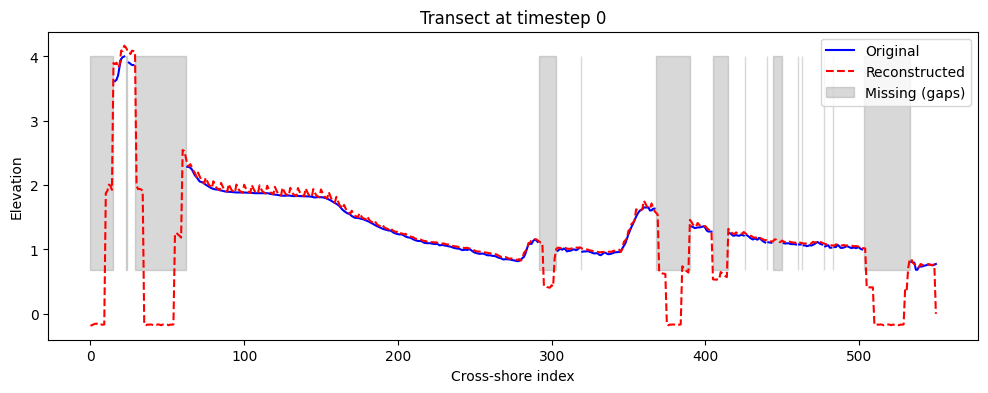

In [ ]:
t = 0  # choose timestep

original = transect_df_raw.values[:, t]
recon = reconstructed_all[:, t]

mask = ~np.isnan(original)

plt.figure(figsize=(12,4))

plt.plot(original, label="Original", color="blue")
plt.plot(recon, label="Reconstructed", color="red", linestyle="--")

# highlight missing regions
plt.fill_between(
    np.arange(len(original)),
    np.nanmin(original),
    np.nanmax(original),
    where=~mask,
    color='gray',
    alpha=0.3,
    label="Missing Gaps"
)

plt.title(f"Transect at timestep {t}")
plt.xlabel("Cross-shore index")
plt.ylabel("Elevation (m)")
plt.legend()
plt.show()

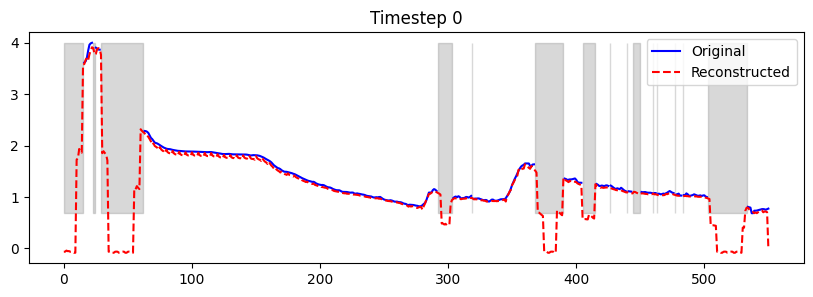

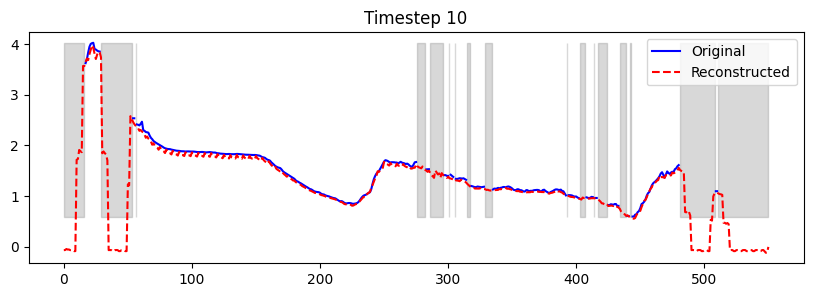

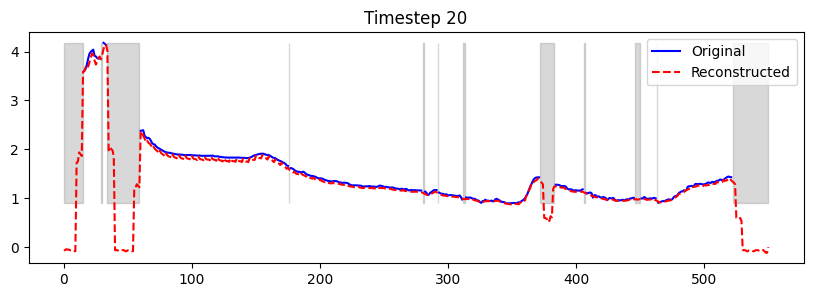

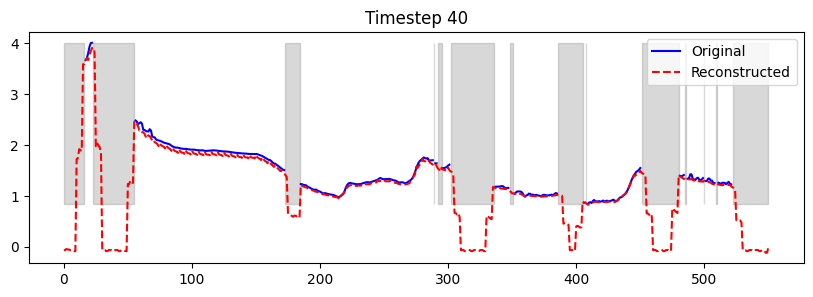

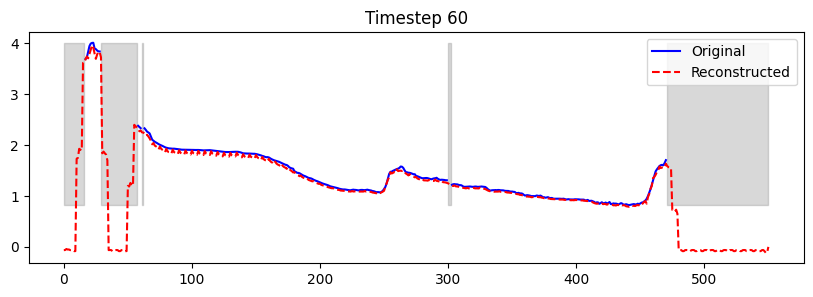

In [100]:
timesteps = [0, 10, 20, 40, 60]

for t in timesteps:
    original = transect_df_raw.values[:, t]
    recon = reconstructed_all[:, t]
    mask = ~np.isnan(original)

    plt.figure(figsize=(10,3))

    plt.plot(original, color='blue', label='Original')
    plt.plot(recon, color='red', linestyle='--', label='Reconstructed')

    plt.fill_between(
        np.arange(len(original)),
        np.nanmin(original),
        np.nanmax(original),
        where=~mask,
        color='gray',
        alpha=0.3
    )

    plt.title(f"Transect at timestep {t}")
    plt.xlabel("Cross-shore index")
    plt.ylabel("Elevation (m)")
    plt.legend()
    plt.show()

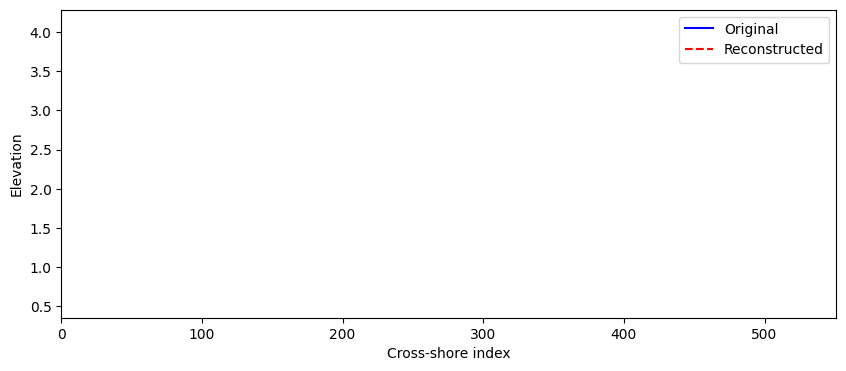

In [ ]:
orig = transect_df_raw.values          # (n_points, n_timesteps)
recon = reconstructed_all              # same shape

from matplotlib.animation import FuncAnimation
# vid of trans
n_points, n_timesteps = orig.shape
x = np.arange(n_points)

fig, ax = plt.subplots(figsize=(10,4))

line_orig, = ax.plot([], [], color='blue', label='Original')
line_recon, = ax.plot([], [], color='red', linestyle='--', label='Reconstructed')
gap_fill = None

ax.set_xlim(0, n_points)
ax.set_ylim(np.nanmin(orig), np.nanmax(orig))
ax.set_xlabel("Cross-shore index")
ax.set_ylabel("Elevation (m)")
ax.legend()

def update(t):
    global gap_fill

    y_orig = orig[:, t]
    y_recon = recon[:, t]

    mask = ~np.isnan(y_orig)

    line_orig.set_data(x, y_orig)
    line_recon.set_data(x, y_recon)

    if gap_fill:
        gap_fill.remove()

    gap_fill = ax.fill_between(
        x,
        np.nanmin(orig),
        np.nanmax(orig),
        where=~mask,
        color='gray',
        alpha=0.3
    )

    ax.set_title(f"Timestep {t}")

    return line_orig, line_recon

anim = FuncAnimation(fig, update, frames=n_timesteps, interval=200)

plt.show()


In [108]:
print(anim.writers.list())

AttributeError: 'FuncAnimation' object has no attribute 'writers'

In [109]:
from matplotlib.animation import FFMpegWriter
writer = FFMpegWriter(fps=5)

In [111]:
anim.save("transects_recon_window10.gif",writer="pillow")

In [110]:
anim.save("transects_animation_window10.mp4", fps=5)

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

In [79]:
autoencoder.summary()

Model: "denoise_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_16 (Sequential)  (None, 2, 8)              2168      
                                                                 
 sequential_17 (Sequential)  (None, 10, 1)             2265      
                                                                 
Total params: 4433 (17.32 KB)
Trainable params: 4433 (17.32 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


OLD

In [241]:
# trying to animate reconstruction

class ReconstructionLogger(tf.keras.callbacks.Callback):
    def __init__(self,sample_batch):
        super().__init__()
        self.sample_batch=sample_batch
        self.history=[]

    def on_epoch_end(self,epoch,logs=None):
        recons=self.model(self.sample_batch)
        self.history.append(recons.numpy())

In [242]:
for x_sample,y_sample in train_ds.take(1):
    break

recon_logger=ReconstructionLogger(x_sample)
# just grab one batch

In [243]:
# start masking at 10% and work you way up
autoencoder=Denoise()
autoencoder.compile(optimizer='adam',loss='mse')

history=autoencoder.fit(
    train_ds,
    epochs=150,
    validation_data=val_ds,
    callbacks=[recon_logger]
)

Epoch 1/150
1648/1648 [==============================] - 22s 13ms/step - loss: 0.0829 - val_loss: 0.0105
Epoch 2/150
1648/1648 [==============================] - 20s 12ms/step - loss: 0.0109 - val_loss: 0.0167
Epoch 3/150
1648/1648 [==============================] - 20s 12ms/step - loss: 0.0087 - val_loss: 0.0035
Epoch 4/150
1648/1648 [==============================] - 21s 13ms/step - loss: 0.0075 - val_loss: 0.0056
Epoch 5/150
1648/1648 [==============================] - 21s 13ms/step - loss: 0.0085 - val_loss: 0.0030
Epoch 6/150
1648/1648 [==============================] - 21s 13ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 7/150
1648/1648 [==============================] - 20s 12ms/step - loss: 0.0090 - val_loss: 0.0025
Epoch 8/150
1648/1648 [==============================] - 20s 12ms/step - loss: 0.0047 - val_loss: 0.0034
Epoch 9/150
1648/1648 [==============================] - 21s 13ms/step - loss: 0.0044 - val_loss: 0.0050
Epoch 10/150
1648/1648 [==============================]

In [244]:
for x_sample,y_sample in train_ds.take(1):
    x_batch,y_batch=x_sample,y_sample

for x_batch in val_ds.take(1):
    recons=autoencoder.predict(x_batch)

ValueError: in user code:

    File "/Users/bagaenzl/Desktop/MAE_info/venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 2341, in predict_function  *
        return step_function(self, iterator)
    File "/Users/bagaenzl/Desktop/MAE_info/venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 2327, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/Users/bagaenzl/Desktop/MAE_info/venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 2315, in run_step  **
        outputs = model.predict_step(data)
    File "/Users/bagaenzl/Desktop/MAE_info/venv/lib/python3.8/site-packages/keras/src/engine/training.py", line 2283, in predict_step
        return self(x, training=False)
    File "/Users/bagaenzl/Desktop/MAE_info/venv/lib/python3.8/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/var/folders/q5/f29tpv4

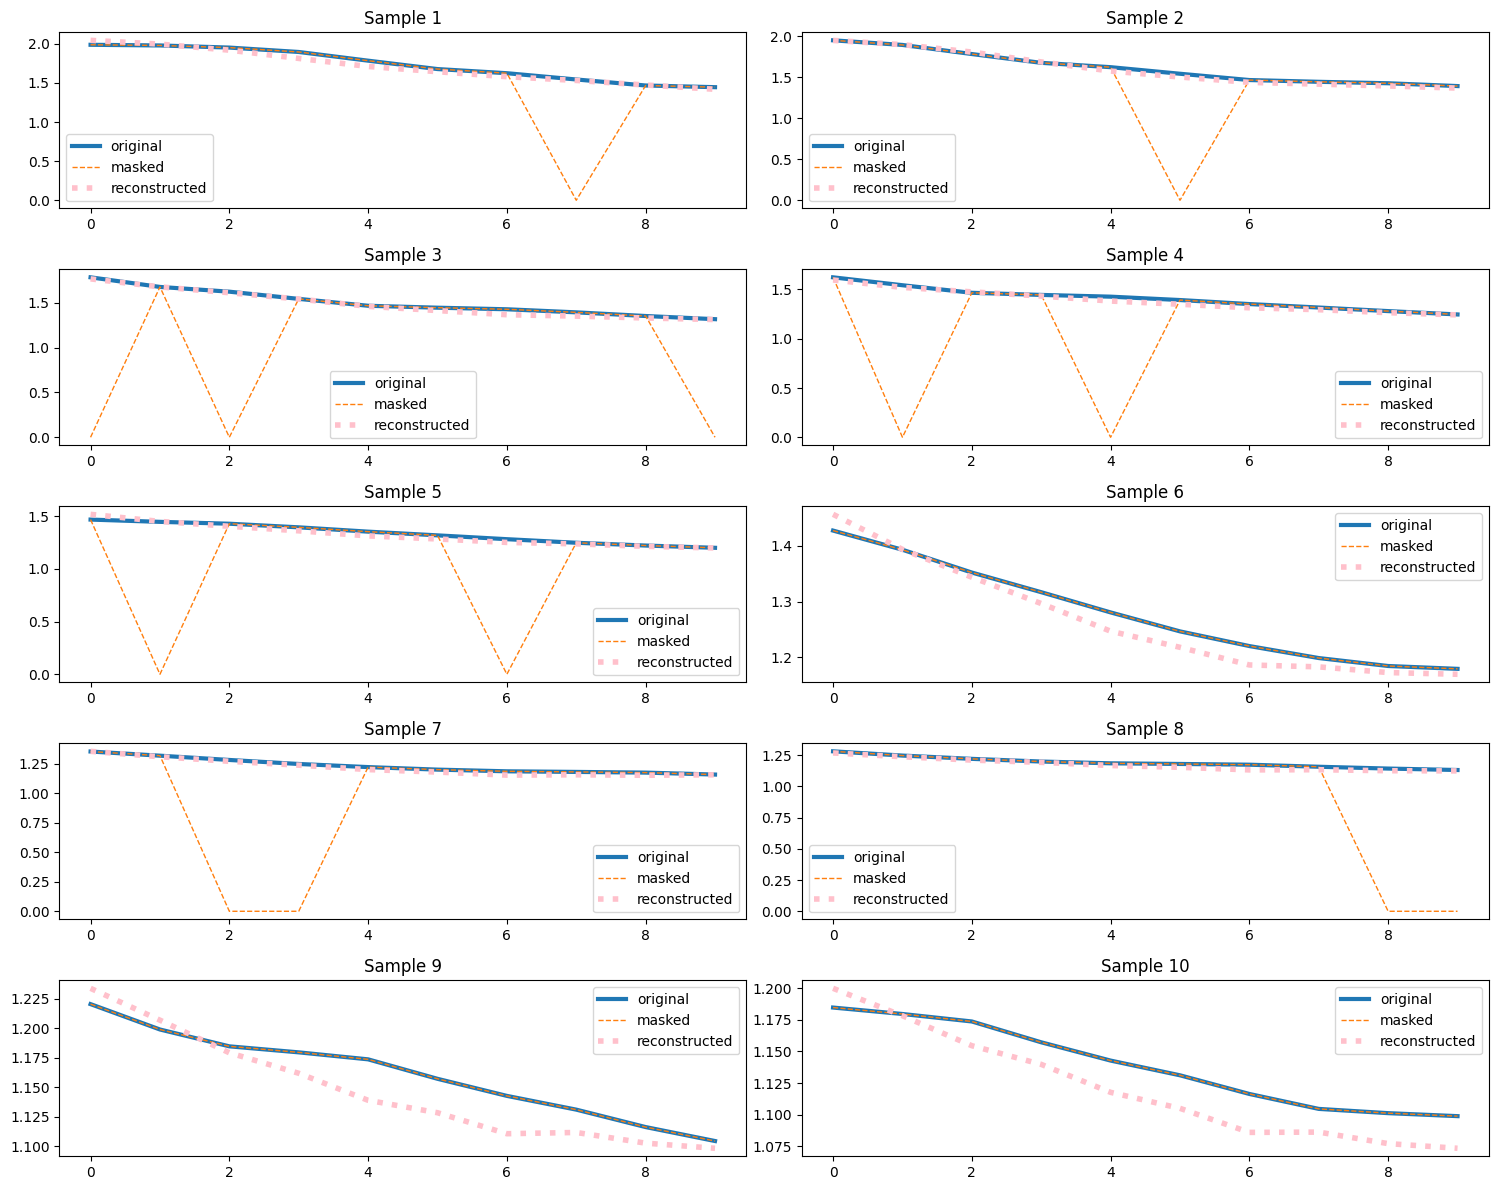

In [223]:
# plotting 
n=10

fig,axes=plt.subplots(nrows=5,ncols=2,figsize=(15,12))
axes=axes.flatten()

for i in range(n):
    #remove channel dimension
    x=x_batch[i].numpy().squeeze()
    y=y_batch[i].numpy().squeeze()
    recon=reconstructed_batch[i].numpy().squeeze()

    axes[i].plot(y,label='original',linewidth=3)
    axes[i].plot(x,label='masked',linestyle="dashed",linewidth=1)
    axes[i].plot(recon,label='reconstructed',linestyle='dotted',linewidth=4,color='pink')
    axes[i].set_title(f"Sample {i+1}")
    axes[i].legend()

plt.tight_layout()
plt.show()


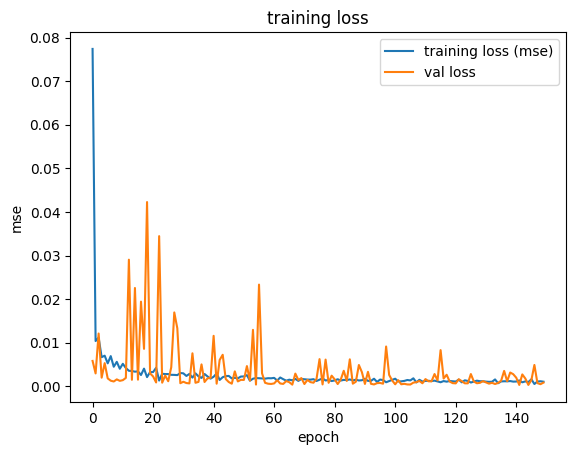

In [224]:
# plot training loss
plt.figure()
plt.plot(history.history['loss'],label='training loss (mse)')
plt.plot(history.history['val_loss'],label='val loss')
plt.legend()
plt.xlabel("epoch")
plt.ylabel('mse')
plt.title('training loss')
plt.show()

# training loss shows how it's learning (rapid learning then levels off) Val loss shows how model performs on unseen data (it's decreasing so yay!)

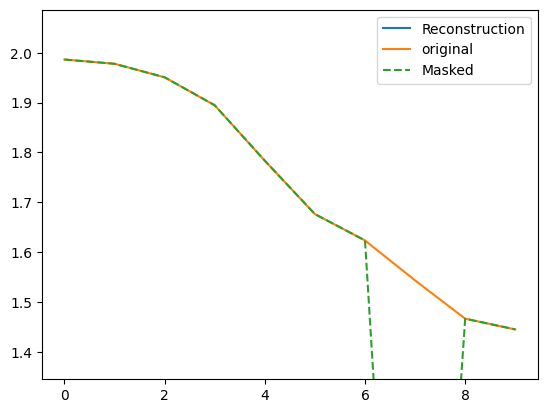

In [225]:
from matplotlib.animation import FuncAnimation

idx=0

y_true=y_sample[idx].numpy().squeeze()
x_input=x_sample[idx].numpy().squeeze()

fig,ax=plt.subplots()

line_recon,=ax.plot([],[],label="Reconstruction")
line_true,=ax.plot(y_true,label='original')
line_input=ax.plot(x_input,linestyle='dashed',label='Masked')

ax.legend()
ax.set_ylim(min(y_true)-0.1,max(y_true)+0.1)

def update(frame):
    recons=recon_logger.history[frame][idx].squeeze()
    line_recon.set_data(range(len(recons)),recons)
    ax.set_title(f"epoch {frame+1}")
    return line_recon,

anim=FuncAnimation(fig,update,frames=len(recon_logger.history),interval=200)

plt.show()

anim.save("reconstruction_01mask_10window.gif",writer="pillow")

In [ ]:
# give MAE the transects and see how it performs

In [ ]:
# increase masking ratio and repeat analysis ( on another notebook maybe)